In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary

In [2]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [3]:
with open("simu2_data/simu2_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
# df_study = df_study.query("session < 100")  # for testing
# df_test = df_test.query("session < 100")

In [4]:
df_study

,subject,list,itemno,study_pos,session
0,37,0,1154,1,0
1,37,0,1121,2,0
2,37,0,612,3,0
3,37,0,907,4,0
4,37,0,1358,5,0
...,...,...,...,...,...
34939,172,5,1243,60,90
34940,172,5,1077,61,90
34941,172,5,1423,62,90
34942,172,5,968,63,90


In [5]:
df_test

,subject,list,recog_pos,itemno,old,old_lag,study_pos,study_lag,yes,session
0,37,0,1,195,True,-999,9,56,1.0,0
1,37,0,2,493,True,46,55,11,0.0,0
2,37,0,3,376,True,-3,52,15,0.0,0
3,37,0,4,998,True,-5,47,21,0.0,0
4,37,0,5,184,False,-999,-99,-9999,0.0,0
...,...,...,...,...,...,...,...,...,...,...
69883,172,5,124,801,False,-999,-99,-9999,0.0,90
69884,172,5,125,1335,False,-999,-99,-9999,1.0,90
69885,172,5,126,1245,True,-999,28,162,1.0,90
69886,172,5,127,747,False,-999,-99,-9999,0.0,90


In [6]:
s_mat = np.load("simu2_data/simu2_smat.npy")

## Run CMR-IA

In [7]:
# define parameters
params = cmr.make_default_params()
params.update(use_new_context=True, beta_distract=0)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="2")
optim_params = np.loadtxt("simu2_data/2_250228_200-200.txt")
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params

{'beta_enc': 0.298298,
 'beta_rec': 0.5,
 'beta_cue': 0.076035,
 'beta_rec_post': 0.28989,
 'beta_distract': 0,
 'phi_s': 2,
 'phi_d': 0.5,
 's_cf': 0,
 's_fc': 0.231917,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 0.5,
 'd_assoc': 1,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'var_enc': 1,
 'bad_enc_ratio': 1,
 'recog_slope': 1,
 'a': 2800,
 'b': 20,
 'gamma_fc': 0.011108,
 'gamma_cf': 0.5}

In [8]:
# task = "Recog"
# mode = "Final"

# sessions = np.unique(df_study.session)
# list_num = len(np.unique(df_study.list))
# df_thin = df_test[["session", "list", "itemno"]]
# df_thin = df_thin.assign(s_resp=np.nan, s_rt=np.nan, csim=np.nan, prob=np.nan)

# for sess in sessions:
#     # extarct the session data
#     pres_mat = df_study.loc[df_study.session == sess, "itemno"].to_numpy()
#     pres_mat = np.reshape(pres_mat, (list_num, -1))
#     cue_mat = df_thin.loc[df_thin.session == sess, "itemno"].to_numpy()
#     cue_mat = np.reshape(cue_mat, (list_num, -1))

#     # run CMR for each session
#     cmr_m = cmr.CMR(params, pres_mat, s_mat, source_mat=None, rec_mat=None, ffr_mat=None, cue_mat=cue_mat, task=task, mode=mode)

#     cmr_m.run_norm_recog_single_sess()

#     recs = cmr_m.rec_items
#     rts = cmr_m.rec_times
#     csims = cmr_m.recog_similarity
#     probs = cmr_m.recog_probability
#     result = np.column_stack((recs, rts, csims, probs))

#     df_thin.loc[df_thin.session == sess, ["s_resp", "s_rt", "csim", "prob"]] = result

In [9]:
# # define parameters
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.4,
#     beta_cue=0.4,
#     beta_distract=0.9,
#     beta_rec_post=0.9,
#     gamma_fc=0.05,
#     s_fc=0.6,
#     use_new_context=True,
# )
# params

In [10]:
# run the model
df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, s_mat)
df_simu

  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [02:00<00:00,  1.32s/it]

CMR Time: 120.32297873497009


,session,list,itemno,s_resp,s_rt,csim,prob
0,0,0,195,0.0,30.398004,0.273850,0.443702
1,0,0,493,0.0,236.914744,0.376516,0.469168
2,0,0,376,0.0,93.719001,0.330146,0.457638
3,0,0,998,0.0,49.776135,0.298508,0.449797
4,0,0,184,0.0,28.407663,0.270464,0.442867
...,...,...,...,...,...,...,...
69883,90,5,801,0.0,74.926718,0.318957,0.454862
69884,90,5,1335,0.0,58.772641,0.306815,0.451853
69885,90,5,1245,0.0,70.993859,0.316261,0.454194
69886,90,5,747,0.0,72.540082,0.317338,0.454461


In [11]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "itemno"])
df_simu

,session,list,itemno,s_resp,s_rt,csim,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes
0,0,0,195,0.0,30.398004,0.273850,0.443702,37,1,True,-999,9,56,1.0
1,0,0,493,0.0,236.914744,0.376516,0.469168,37,2,True,46,55,11,0.0
2,0,0,376,0.0,93.719001,0.330146,0.457638,37,3,True,-3,52,15,0.0
3,0,0,998,0.0,49.776135,0.298508,0.449797,37,4,True,-5,47,21,0.0
4,0,0,184,0.0,28.407663,0.270464,0.442867,37,5,False,-999,-99,-9999,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69883,90,5,801,0.0,74.926718,0.318957,0.454862,172,124,False,-999,-99,-9999,0.0
69884,90,5,1335,0.0,58.772641,0.306815,0.451853,172,125,False,-999,-99,-9999,1.0
69885,90,5,1245,0.0,70.993859,0.316261,0.454194,172,126,True,-999,28,162,1.0
69886,90,5,747,0.0,72.540082,0.317338,0.454461,172,127,False,-999,-99,-9999,0.0


In [12]:
# calculate loss
s_resp = df_simu["s_resp"].values
yes = df_simu["yes"].values
err = np.nansum(np.abs(s_resp - yes))
err

32697.0

In [13]:
if SAVERES:
    df_simu.to_pickle("simu2_data/simu2_result.pkl")

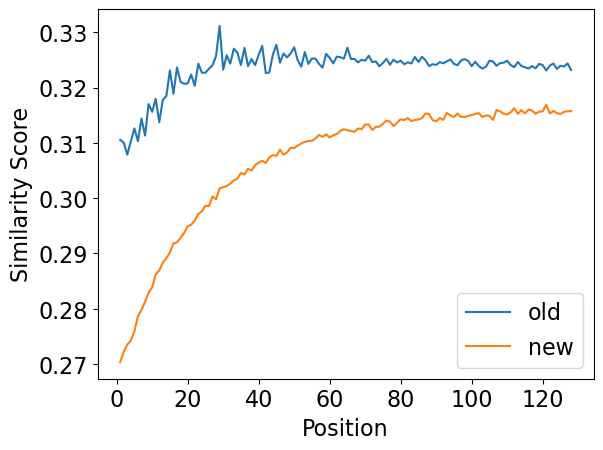

In [18]:
old_csim_pos = df_simu.query("old == True").groupby("recog_pos").csim.mean()
old_pos = np.unique(df_simu.query("old == True").recog_pos.values)
new_csim_pos = df_simu.query("old == False").groupby("recog_pos").csim.mean()
new_pos = np.unique(df_simu.query("old == False").recog_pos.values)

plt.plot(old_pos, old_csim_pos, label="old")
plt.plot(new_pos, new_csim_pos, label="new")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
plt.show()

## Analysis

In [15]:
# with open("simu2_data/simu2_result.pkl", "rb") as inp:
#     df_simu = pickle.load(inp)

In [16]:
def conditions(s):
    if s.old_lag == -999:
        return np.nan
    elif np.absolute(s.old_lag) == 1:
        return "a"
    elif np.absolute(s.old_lag) > 10:
        return "r"
    else:
        return np.nan


df_simu["lag_cat"] = df_simu.apply(conditions, axis=1)
df_simu

,session,list,itemno,s_resp,s_rt,csim,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat
0,0,0,195,0.0,30.398004,0.273850,0.443702,37,1,True,-999,9,56,1.0,NaN
1,0,0,493,0.0,236.914744,0.376516,0.469168,37,2,True,46,55,11,0.0,r
2,0,0,376,0.0,93.719001,0.330146,0.457638,37,3,True,-3,52,15,0.0,NaN
3,0,0,998,0.0,49.776135,0.298508,0.449797,37,4,True,-5,47,21,0.0,NaN
4,0,0,184,0.0,28.407663,0.270464,0.442867,37,5,False,-999,-99,-9999,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69883,90,5,801,0.0,74.926718,0.318957,0.454862,172,124,False,-999,-99,-9999,0.0,NaN
69884,90,5,1335,0.0,58.772641,0.306815,0.451853,172,125,False,-999,-99,-9999,1.0,NaN
69885,90,5,1245,0.0,70.993859,0.316261,0.454194,172,126,True,-999,28,162,1.0,NaN
69886,90,5,747,0.0,72.540082,0.317338,0.454461,172,127,False,-999,-99,-9999,0.0,NaN


In [17]:
# check overall HR and FAR
df_overall = df_simu.groupby(["subject", "old"]).s_resp.mean().reset_index()
hr = df_overall.groupby(["old"]).s_resp.mean()[True]
far = df_overall.groupby(["old"]).s_resp.mean()[False]
hr, far

(0.0014308608058608058, 0.0)

In [18]:
far = df_simu.query("old==False").s_resp.mean()
far

0.0

In [19]:
df_overall = df_simu.query("old==True").groupby(["subject", "lag_cat"]).s_resp.mean().reset_index()
hr_a = df_overall.groupby(["lag_cat"]).s_resp.mean()["a"]
hr_r = df_overall.groupby(["lag_cat"]).s_resp.mean()["r"]
hr_a, hr_r

(0.0006868131868131869, 0.0009223414946755415)

In [20]:
# # calcualte err
# err_min = 1
# csim_thresh_min = 0

# for csim_thresh in np.arange(0, 1, 0.002):

#     df_simu["s_resp"] = df_simu["csim"] > csim_thresh

#     far = df_simu.query("old==False").s_resp.mean()
#     df_overall = df_simu.query("old==True").groupby(["subject", "lag_cat"]).s_resp.mean().reset_index()
#     hr_a = df_overall.groupby(["lag_cat"]).s_resp.mean()["a"]
#     hr_r = df_overall.groupby(["lag_cat"]).s_resp.mean()["r"]

#     hr_a_gt = 0.724046
#     hr_r_gt = 0.693084
#     far_gt = 0.268861
#     err = (np.abs(hr_a - hr_a_gt) + np.abs(hr_r - hr_r_gt)) / 2 + np.abs(far - far_gt)

#     if err < err_min:
#         err_min = err
#         csim_thresh_min = csim_thresh

#     print(err)

# err_min, csim_thresh_min

# # maunal csim_thresh
# df_simu["s_resp"] = df_simu["csim"] > csim_thresh_min

# far = df_simu.query("old==False").s_resp.mean()
# df_overall = df_simu.query("old==True").groupby(["subject", "lag_cat"]).s_resp.mean().reset_index()
# hr_a = df_overall.groupby(["lag_cat"]).s_resp.mean()["a"]
# hr_r = df_overall.groupby(["lag_cat"]).s_resp.mean()["r"]

# far, hr_a, hr_r

In [21]:
# calculate err
hr_a_gt = 0.724046
hr_r_gt = 0.693084
far_gt = 0.268861
err = (np.abs(hr_a - hr_a_gt) + np.abs(hr_r - hr_r_gt)) / 2 + np.abs(far - far_gt)
err

0.9766214226592557

In [22]:
# construct local FAR
# contiguous items, but only need to consider previous items, since post items with condition is always old
recog_pos = df_simu.recog_pos.values
old = df_simu.old.values
lag_cat = df_simu.lag_cat.values
lag_cat_with_new = []
for i in range(len(df_simu)):
    if recog_pos[i] > 1:
        if not old[i] and old[i - 1]:
            lag_cat_with_new.append(lag_cat[i - 1])
        else:
            lag_cat_with_new.append(lag_cat[i])
    else:
        lag_cat_with_new.append(lag_cat[i])
df_simu["lag_cat"] = lag_cat_with_new
df_simu

,session,list,itemno,s_resp,s_rt,csim,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat
0,0,0,195,0.0,30.398004,0.273850,0.443702,37,1,True,-999,9,56,1.0,NaN
1,0,0,493,0.0,236.914744,0.376516,0.469168,37,2,True,46,55,11,0.0,r
2,0,0,376,0.0,93.719001,0.330146,0.457638,37,3,True,-3,52,15,0.0,NaN
3,0,0,998,0.0,49.776135,0.298508,0.449797,37,4,True,-5,47,21,0.0,NaN
4,0,0,184,0.0,28.407663,0.270464,0.442867,37,5,False,-999,-99,-9999,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69883,90,5,801,0.0,74.926718,0.318957,0.454862,172,124,False,-999,-99,-9999,0.0,r
69884,90,5,1335,0.0,58.772641,0.306815,0.451853,172,125,False,-999,-99,-9999,1.0,NaN
69885,90,5,1245,0.0,70.993859,0.316261,0.454194,172,126,True,-999,28,162,1.0,NaN
69886,90,5,747,0.0,72.540082,0.317338,0.454461,172,127,False,-999,-99,-9999,0.0,NaN


In [23]:
df_simu.groupby(["old", "lag_cat"]).old.count()  # diff from simu2_Schwartz.ipynb a bit because here is no rt removal

old    lag_cat
False  a           740
       r          4065
True   a          1159
       r          9460
Name: old, dtype: int64

In [24]:
df_t = df_simu.loc[pd.notna(df_simu.lag_cat)].copy()
df_t

,session,list,itemno,s_resp,s_rt,csim,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat
1,0,0,493,0.0,236.914744,0.376516,0.469168,37,2,True,46,55,11,0.0,r
10,0,0,996,0.0,40.421783,0.288100,0.447222,37,11,True,-13,27,48,1.0,r
11,0,0,1398,0.0,48.670208,0.297385,0.449519,37,12,False,-999,-99,-9999,0.0,r
17,0,0,285,0.0,50.574210,0.299303,0.449994,37,18,True,-26,7,75,0.0,r
22,0,0,380,0.0,85.281396,0.325429,0.456468,37,23,True,11,50,37,NaN,r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69853,90,5,48,0.0,99.940501,0.333360,0.458436,172,94,True,-16,20,138,0.0,r
69865,90,5,723,0.0,87.044580,0.326452,0.456722,172,106,True,19,59,111,1.0,r
69866,90,5,724,0.0,88.700876,0.327395,0.456956,172,107,True,-56,3,168,1.0,r
69882,90,5,1310,0.0,77.924231,0.320918,0.455349,172,123,True,-23,38,149,1.0,r


In [25]:
create_level = {0: "new_r", 1: "new_a", 2: "old_r", 3: "old_a"}
df_t["level"] = df_t.apply(lambda x: create_level[x["old"] * 2 + (x["lag_cat"] == "a")], axis=1)
df_t

,session,list,itemno,s_resp,s_rt,csim,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat,level
1,0,0,493,0.0,236.914744,0.376516,0.469168,37,2,True,46,55,11,0.0,r,old_r
10,0,0,996,0.0,40.421783,0.288100,0.447222,37,11,True,-13,27,48,1.0,r,old_r
11,0,0,1398,0.0,48.670208,0.297385,0.449519,37,12,False,-999,-99,-9999,0.0,r,new_r
17,0,0,285,0.0,50.574210,0.299303,0.449994,37,18,True,-26,7,75,0.0,r,old_r
22,0,0,380,0.0,85.281396,0.325429,0.456468,37,23,True,11,50,37,NaN,r,old_r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69853,90,5,48,0.0,99.940501,0.333360,0.458436,172,94,True,-16,20,138,0.0,r,old_r
69865,90,5,723,0.0,87.044580,0.326452,0.456722,172,106,True,19,59,111,1.0,r,old_r
69866,90,5,724,0.0,88.700876,0.327395,0.456956,172,107,True,-56,3,168,1.0,r,old_r
69882,90,5,1310,0.0,77.924231,0.320918,0.455349,172,123,True,-23,38,149,1.0,r,old_r


<Axes: xlabel='csim', ylabel='Probability'>

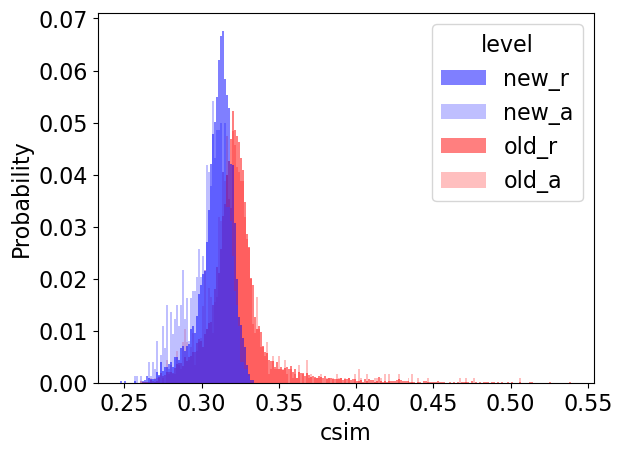

In [26]:
sns.histplot(
    data=df_t,
    x="csim",
    hue="level",
    hue_order=["new_r", "new_a", "old_r", "old_a"],
    palette=[[0, 0, 1], [0.5, 0.5, 1], [1, 0, 0], [1, 0.5, 0.5]],
    stat="probability",
    common_norm=False,
    edgecolor=None,
)

### ROC

In [27]:
thresh_arr = np.arange(0, 1, 0.001)
df_thin = df_t.loc[:, ["csim", "level", "session"]]
df_roc = pd.DataFrame()
for t in thresh_arr:
    df_thin["above"] = df_thin.csim > t
    df_sess_lv = df_thin.groupby(["session", "level"]).above.mean().to_frame(name="above")
    df_lv = df_sess_lv.groupby("level").above.mean()
    df_roc = pd.concat([df_roc, df_lv], axis=1, ignore_index=True)
df_roc = df_roc.transpose()
df_roc

,new_a,new_r,old_a,old_r
0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0
...,...,...,...,...
995,0.0,0.0,0.0,0.0
996,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0
998,0.0,0.0,0.0,0.0


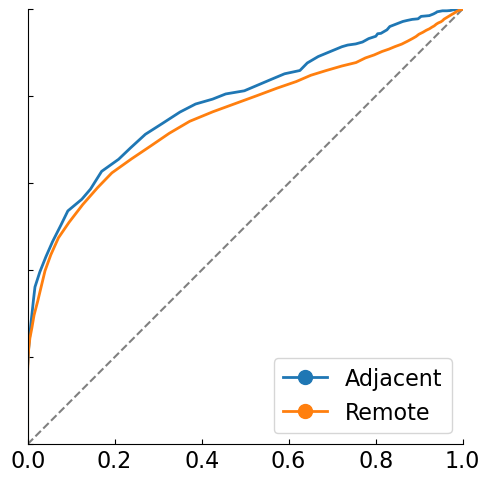

In [28]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
x = np.array([0, 1])
y = np.array([0, 1])
ax.plot(x, y, color="grey", linestyle="dashed")
sns.lineplot(data=df_roc, x="new_a", y="old_a", marker=None, ax=ax, estimator=None, label="adjacent", linewidth=2)
sns.lineplot(data=df_roc, x="new_r", y="old_r", marker=None, ax=ax, estimator=None, label="remote", linewidth=2)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

if SAVEFIG:
    plt.savefig("simu2_fig/simu2_roc.pdf")

### ZROC

In [29]:
df_zroc = pd.DataFrame()
df_zroc["z_new_a"] = sp.stats.norm.ppf(df_roc["new_a"])
df_zroc["z_new_r"] = sp.stats.norm.ppf(df_roc["new_r"])
df_zroc["z_old_a"] = sp.stats.norm.ppf(df_roc["old_a"])
df_zroc["z_old_r"] = sp.stats.norm.ppf(df_roc["old_r"])
df_zroc

,z_new_a,z_new_r,z_old_a,z_old_r
0,inf,inf,inf,inf
1,inf,inf,inf,inf
2,inf,inf,inf,inf
3,inf,inf,inf,inf
4,inf,inf,inf,inf
...,...,...,...,...
995,-inf,-inf,-inf,-inf
996,-inf,-inf,-inf,-inf
997,-inf,-inf,-inf,-inf
998,-inf,-inf,-inf,-inf


In [30]:
df_zroc_plot = df_zroc.query("-2 < z_new_a < 1 and -2 < z_new_r < 1")
df_zroc_plot

,z_new_a,z_new_r,z_old_a,z_old_r
301,0.434271,0.955983,1.231827,1.328898
302,0.366272,0.895613,1.156581,1.296755
303,0.321149,0.829136,1.075548,1.251815
304,0.229220,0.760351,1.042360,1.214914
305,0.149056,0.690059,0.987119,1.161254
306,0.081218,0.590660,0.941785,1.123290
307,-0.004501,0.487055,0.886356,1.075972
308,-0.112283,0.388067,0.859678,1.027746
309,-0.188450,0.298777,0.817331,0.968139
310,-0.289669,0.185378,0.778518,0.909387


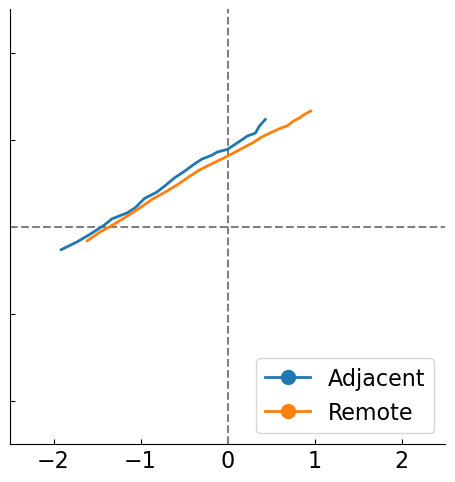

In [31]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.axvline(x=0, color="grey", linestyle="dashed")
plt.axhline(y=0, color="grey", linestyle="dashed")
sns.lineplot(data=df_zroc_plot, x="z_new_a", y="z_old_a", marker=None, ax=ax, estimator=None, label="adjacent", linewidth=2)
sns.lineplot(data=df_zroc_plot, x="z_new_r", y="z_old_r", marker=None, ax=ax, estimator=None, label="remote", linewidth=2)
plt.ylim([-2.5, 2.5])
plt.xlim([-2.5, 2.5])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

if SAVEFIG:
    plt.savefig("simu2_fig/simu2_zroc.pdf")

### Err Check

In [32]:
with open("simu2_data/simu2_gt.pkl", "rb") as f:
    far_a_gt = pickle.load(f)
    hr_a_gt = pickle.load(f)
    far_r_gt = pickle.load(f)
    hr_r_gt = pickle.load(f)
far_a_gt, hr_a_gt, far_r_gt, hr_r_gt

(array([0.63711283, 0.40206155, 0.30077981, 0.17914973, 0.08653044]),
 array([0.87285191, 0.77504082, 0.72404606, 0.63873151, 0.53393667]),
 array([0.66120193, 0.42479231, 0.30588907, 0.17987607, 0.08935513]),
 array([0.87874116, 0.76308836, 0.69308383, 0.60104811, 0.50378656]))

In [33]:
far_a = np.sort(df_roc["new_a"].values)
hr_a = np.sort(df_roc["old_a"].values)
far_r = np.sort(df_roc["new_r"].values)
hr_r = np.sort(df_roc["old_r"].values)

# far_a_gt = np.array([0.63711283, 0.40206155, 0.30077981, 0.17914973, 0.08653044])
# hr_a_gt = np.array([0.87285191, 0.77504082, 0.72404606, 0.63873151, 0.53393667])
# far_r_gt = np.array([0.66120193, 0.42479231, 0.30588907, 0.17987607, 0.08935513])
# hr_r_gt = np.array([0.87874116, 0.76308836, 0.69308383, 0.60104811, 0.50378656])

In [34]:
hr_a_interp = []
for x in far_a_gt:
    idx = np.searchsorted(far_a, x)
    if idx < len(far_a):
        tmp_interp = hr_a[idx - 1] + (x - far_a[idx - 1]) * (hr_a[idx] - hr_a[idx - 1]) / (far_a[idx] - far_a[idx - 1])
    else:
        tmp_interp = hr_a[idx - 1]
        print("Warning: far_a_gt out of range")
    hr_a_interp.append(tmp_interp)
hr_a_interp = np.array(hr_a_interp)
hr_a_interp

array([0.87034365, 0.78646956, 0.73147991, 0.63349828, 0.52400865])

In [35]:
hr_r_interp = []
for x in far_r_gt:
    idx = np.searchsorted(far_r, x)
    if idx < len(far_r):
        tmp_interp = hr_r[idx - 1] + (x - far_r[idx - 1]) * (hr_r[idx] - hr_r[idx - 1]) / (far_r[idx] - far_r[idx - 1])
    else:
        tmp_interp = hr_r[idx - 1]
        print("Warning: far_r_gt out of range")
    hr_r_interp.append(tmp_interp)
hr_r_interp = np.array(hr_r_interp)
hr_r_interp

array([0.8511068 , 0.76366709, 0.70112862, 0.60932474, 0.5013563 ])

In [36]:
err = np.power(hr_a_interp - hr_a_gt, 2).sum() + np.power(hr_r_interp - hr_r_gt, 2).sum()
err

0.0012212420849880823

In [37]:
np.all((hr_a_interp > hr_r_interp)[1:])

True

In [38]:
# ensure a is above r in a range
above_range = np.arange(0.08, 0.61, 0.01)
hr_a_interp_range = []
for x in above_range:
    idx = np.searchsorted(far_a, x)
    if idx < len(far_a):
        tmp_interp = hr_a[idx - 1] + (x - far_a[idx - 1]) * (hr_a[idx] - hr_a[idx - 1]) / (far_a[idx] - far_a[idx - 1])
    else:
        tmp_interp = hr_a[idx - 1]
        print("Warning: above_range out of range")
    hr_a_interp_range.append(tmp_interp)
hr_a_interp_range = np.array(hr_a_interp_range)
hr_r_interp_range = []
for x in above_range:
    idx = np.searchsorted(far_r, x)
    if idx < len(far_r):
        tmp_interp = hr_r[idx - 1] + (x - far_r[idx - 1]) * (hr_r[idx] - hr_r[idx - 1]) / (far_r[idx] - far_r[idx - 1])
    else:
        tmp_interp = hr_r[idx - 1]
        print("Warning: above_range out of range")
    hr_r_interp_range.append(tmp_interp)
hr_r_interp_range = np.array(hr_r_interp_range)

In [39]:
np.all(hr_a_interp_range > hr_r_interp_range)

True

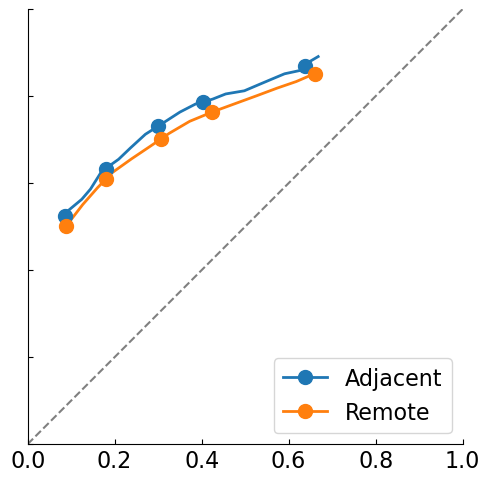

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
x = np.array([0, 1])
y = np.array([0, 1])
ax.plot(x, y, color="grey", linestyle="dashed")
sns.lineplot(data=df_roc.query("0.08 <= new_a <= 0.67"), x="new_a", y="old_a", marker=None, ax=ax, estimator=None, label="adjacent", linewidth=2)
sns.lineplot(data=df_roc.query("0.08 <= new_r <= 0.67"), x="new_r", y="old_r", marker=None, ax=ax, estimator=None, label="remote", linewidth=2)
plt.plot(far_a_gt, hr_a_interp, color=sns.color_palette()[0], marker="o", linestyle="None", markersize=10)
plt.plot(far_r_gt, hr_r_interp, color=sns.color_palette()[1], marker="o", linestyle="None", markersize=10)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

if SAVEFIG:
    plt.savefig("simu2_fig/simu2_roc.pdf")